# Multi-Machine Database Comparison

## Overview

`multiple_tokamak_comparison.ipynb` asks whether different machines and file formats reach one
equilibrium representation. This notebook asks the harder question of #1205: can **published
multi-machine scientific databases**, each with its own schema, units and conventions, be mapped
into common VAFT semantics and compared with VEST through the same analysis API?

```
published database -> source-specific reader -> semantic normalisation -> canonical table / ODS
VEST canonical layer ----------------------------------------------------^           |
                                                     physics-named analysis and plots <-
```

Three data classes, each kept in the representation that fits it (#1205 §2):

| Class | Database | Canonical representation |
|---|---|---|
| global / scaling | ITPA DB5.2.3 H-mode confinement | confinement table (`vaft.data.public.CONFINEMENT_COLUMNS`) |
| transition / event | TCV public L–H set, ITPA TC-26 metal-wall L–H | transition table (`TRANSITION_COLUMNS`), event named explicitly |
| profile | ITPA PR08 profile database | ODS: `core_profiles`, `equilibrium` subset, `core_sources`, `core_transport` |

Dataset types are never mixed silently: every row and every IDS says where it came from and how
each quantity was defined. **Missing in the source stays missing here.**

What this notebook does not do: reproduce the databases' own pipelines, fill gaps, ingest the
databases into the VEST database, or fit new scalings.

## Setup

Downloads go to the per-user VAFT cache (`$VAFT_PUBLIC_DATA_DIR` overrides it) and are verified
against pinned SHA-256 hashes. `FetchError` means the upstream could not be reached -- an outage,
not a VAFT defect -- and each section below carries on without the dataset that failed.

The TC-26 database is read only from a local copy: its auxiliary file sits behind a bot check on
the publisher's site and states no licence, so VAFT neither downloads nor ships it. Set
`VAFT_TC26_CSV` to the downloaded `nfae39f2supp2.csv` to include it.

In [ ]:
import os

# Pick the rendering backend explicitly: inline in a Jupyter kernel,
# headless Agg in a plain `python` run.
try:
    _ipython = get_ipython()
except NameError:
    _ipython = None
if _ipython is None:
    os.environ.setdefault("MPLBACKEND", "Agg")
elif "IPKernelApp" in _ipython.config:
    _ipython.run_line_magic("matplotlib", "inline")

import datetime
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import vaft
from vaft.data import public
from vaft.data.public import FetchError
from vaft.data.public.itpa_profile import PR08_REFERENCE
from vaft.data.public.itpa_tc26 import TC26_SHA256
from vaft.plot import population

# The packaged VEST sample predates DD-version stamping; omas falls back to 3.41.0.
warnings.filterwarnings("ignore", message="Could not infer an IMAS DD version")

pd.set_option("display.max_colwidth", 90)
pd.set_option("display.width", 160)

status = {}


def attempt(name, load):
    # Run one load; record an upstream outage separately from a VAFT failure.
    try:
        value = load()
    except FetchError as error:
        status[name] = f"upstream unavailable -- {error}"
        return None
    except Exception as error:  # a reader or mapping defect, reported, not hidden
        status[name] = f"failed in VAFT -- {type(error).__name__}: {error}"
        return None
    status[name] = "ok"
    return value

## 1. Public database provenance and access

Access and licence were checked before any code was written (stage 0 of #1205). The registry
below is what VAFT pins; the policy column is what that audit allows.

In [ ]:
sources = public.SOURCES
access = pd.DataFrame([
    {
        "database": sources["itpa_db5.2.3"].database,
        "release": sources["itpa_db5.2.3"].release,
        "class": "global confinement",
        "licence": sources["itpa_db5.2.3"].licence,
        "VAFT access": "automatic fetch, pinned SHA-256",
        "cite": sources["itpa_db5.2.3"].reference,
    },
    {
        "database": sources["tcv_lh_2025"].database,
        "release": sources["tcv_lh_2025"].release,
        "class": "L-H transition",
        "licence": sources["tcv_lh_2025"].licence,
        "VAFT access": "automatic fetch, pinned SHA-256",
        "cite": sources["tcv_lh_2025"].reference,
    },
    {
        "database": "ITPA TC-26 metal-wall L-H threshold database",
        "release": "Nucl. Fusion 66 (2026) 036016, auxiliary file",
        "class": "L-H transition",
        "licence": "article CC BY 4.0; auxiliary file states none",
        "VAFT access": "local path only ($VAFT_TC26_CSV); not redistributed",
        "cite": "E. Delabie et al., Nucl. Fusion 66 (2026) 036016",
    },
    {
        "database": "ITPA International Multi-Tokamak Profile Database",
        "release": "PR08 public release",
        "class": "profiles",
        "licence": "use and publication allowed with citation; redistribution not addressed",
        "VAFT access": "automatic fetch per discharge, pinned SHA-256 per file",
        "cite": PR08_REFERENCE,
    },
])
access

                                            database                                        release               class  \
0            ITPA global H-mode confinement database                                        DB5.2.3  global confinement   
1      TCV L-H transition database (limited dataset)                   Zenodo 14996664 (2025-03-09)      L-H transition   
2       ITPA TC-26 metal-wall L-H threshold database  Nucl. Fusion 66 (2026) 036016, auxiliary file      L-H transition   
3  ITPA International Multi-Tokamak Profile Database                            PR08 public release            profiles   

                                                                   licence                                             VAFT access  \
0                                                                CC BY 4.0                         automatic fetch, pinned SHA-256   
1                                                                CC BY 4.0                         automatic fetch, 

## 2. Global confinement population

DB5.2.3 is read with its own column names and normalised into the canonical confinement table
(strict SI, magnitudes of IP and BT, `epsilon = AMIN/RGEO`, missing as NaN). The analysis below
uses only canonical column names.

The first check pins the unit handling end to end: VAFT's IPB98(y,2) prediction, evaluated by the
existing `vaft.formula.confinement_time_from_engineering_parameters`, must reproduce DB5's own
stored H-factor `HIPB98Y2 / TAUC92`.

In [ ]:
db5_raw = attempt("DB5.2.3", public.read_db5)
db5 = public.normalize_db5(db5_raw) if db5_raw is not None else public.empty_confinement_table()
standard = db5[db5["selected"]].reset_index(drop=True)
print(f"DB5.2.3: {len(db5)} records, {len(standard)} in the SELDB5 standard set, "
      f"{db5['machine'].nunique()} machines")

if len(db5):
    ratio = public.h_factor(db5, "H98y2") / (db5_raw["HIPB98Y2"] / db5_raw["TAUC92"])
    ratio = ratio[np.isfinite(ratio)]
    print(f"VAFT H98 / DB5 HIPB98Y2: {len(ratio)} comparable records, "
          f"{int((abs(ratio - 1) < 2e-3).sum())} agree within 0.2 % "
          f"(DB5 stores HIPB98Y2 to about 4 significant figures)")
    print(f"median H98 over the standard set: {public.h_factor(standard, 'H98y2').median():.3f}")

DB5.2.3: 14153 records, 7568 in the SELDB5 standard set, 19 machines


VAFT H98 / DB5 HIPB98Y2: 11471 comparable records, 11470 agree within 0.2 % (DB5 stores HIPB98Y2 to about 4 significant figures)


median H98 over the standard set: 0.999


VEST enters through its canonical layer, never through notebook-side extraction. The rows are lane D's Tier A confinement table (#548): one row per magnetics EFIT state key of contract v1
(#1454), with a measured ohmic power balance -- $P_{OH}$ from the inboard loop voltage minus the
internal inductive voltage, $dW/dt$ from the EFIT time base, $P_{loss} = P_{OH} - dW/dt$ with
radiation *not* subtracted, as in DB5 `PLTH`. It is packaged as a derived sample under
`vaft/data/confinement/` (provenance in its `manifest.json`), so this section runs without the
VEST database. The primary selection of #1490 keeps 59 quasi-stationary slices of 19 shots.

One caveat travels with these rows: most 429xx--430xx slices are Thomson-inconsistent under criteria
v2 (#1521) -- their magnetics-EFIT pressure exceeds what Thomson scattering allows -- so their
$\tau_E$ may be biased high; `thomson_consistent` marks every row (#1490).

`public.load_vest_tier_a_confinement` reads it: canonical columns validated by the same
`validate_confinement_table` as DB5, then lane D's extension columns and `tier_a_block`.

In [ ]:
# The packaged kinetic-EFIT slice 48224 stays the VEST profile of section 3; it has no
# magnetics, so it carries no tau_E and is not a confinement row.
vest_ods = vaft.omas.load(vaft.data.data_path("kineticEfit/ods_48224_300ms.json"))

vest_tier_a = public.load_vest_tier_a_confinement("primary")       # lane D, #548
vest = vest_tier_a[list(public.CONFINEMENT_COLUMNS)]
print(f"VEST Tier A: {len(vest)} rows of {vest['shot'].nunique()} shots, "
      f"blocks {vest_tier_a['tier_a_block'].value_counts().to_dict()}")
columns = ["record_id", "i_p_A", "b_t_T", "n_e_line_avg_m3", "p_loss_W", "tau_e_th_s",
           "r_geo_m", "epsilon", "kappa", "kappa_area", "delta"]
vest[columns].describe().loc[["count", "min", "50%", "max"]]

VEST Tier A: 59 rows of 19 shots, blocks {'399xx-403xx': 30, '429xx-430xx': 29}


          i_p_A      b_t_T  n_e_line_avg_m3   p_loss_W  tau_e_th_s    r_geo_m    epsilon     kappa  kappa_area      delta
count      59.0  59.000000     3.100000e+01       59.0   59.000000  59.000000  59.000000  59.00000    59.00000  59.000000
min     44902.5   0.139557     3.792720e+18    47826.9    0.000462   0.324075   0.675951   1.35001     1.22625   0.235472
50%     81462.6   0.163828     9.240070e+18   190516.0    0.001458   0.398136   0.735762   1.54106     1.41410   0.313539
max    175328.0   0.213112     1.764730e+19  1604220.0    0.002331   0.438580   0.754993   1.77558     1.58442   0.457209

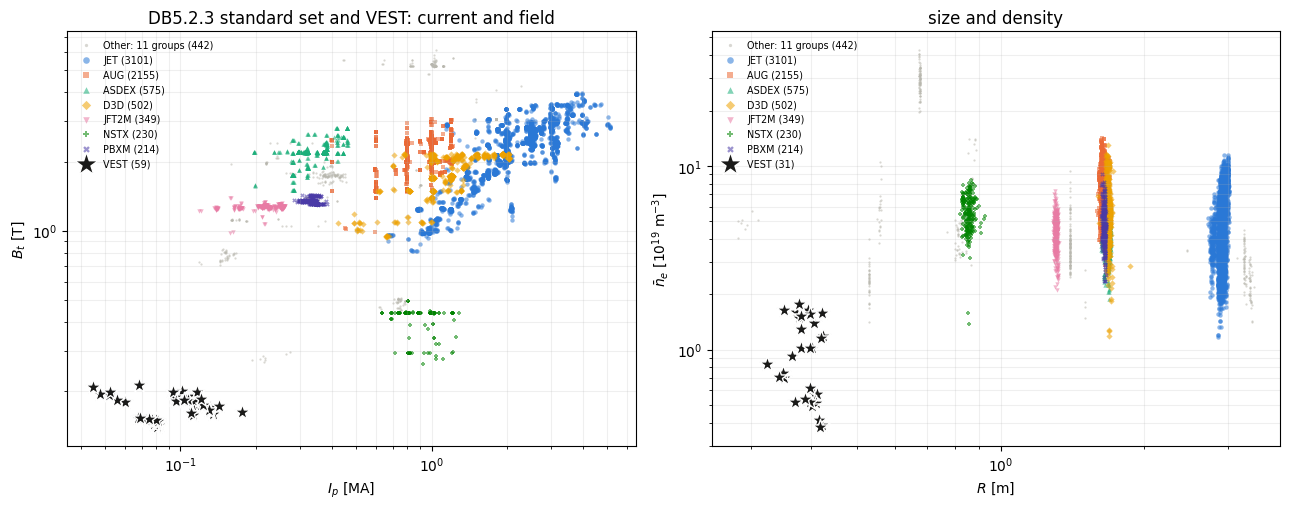

In [ ]:
confinement = public.validate_confinement_table(pd.concat([standard, vest], ignore_index=True))
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
population.confinement_population(confinement, "i_p_A", "b_t_T", ax=axes[0])
population.confinement_population(confinement, "r_geo_m", "n_e_line_avg_m3", ax=axes[1])
axes[0].set_title("DB5.2.3 standard set and VEST: current and field")
axes[1].set_title("size and density")
fig.tight_layout()
plt.show()

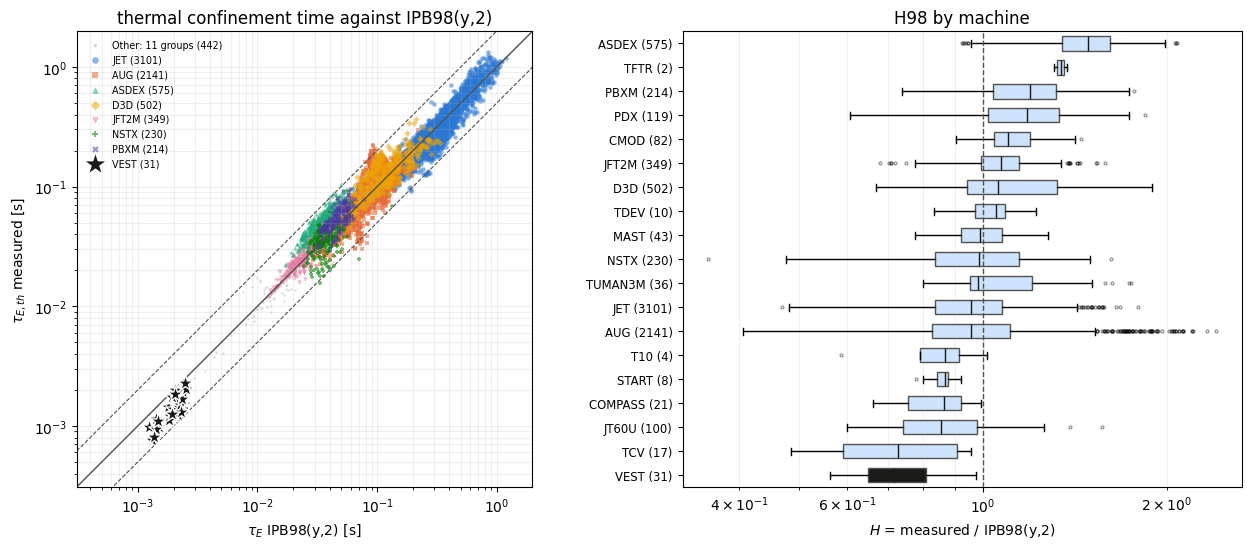

VEST 399xx-403xx: H98 median 0.72 over 15 rows with a Thomson density (ohmic L-mode: H98 locates VEST, it does not rate it)
VEST 429xx-430xx: H98 median 0.69 over 16 rows with a Thomson density (ohmic L-mode: H98 locates VEST, it does not rate it)


In [ ]:
from vaft.data.public.vest_confinement import VEST_TIER_A_BLOCK_SPLIT_SHOT

predicted = public.predict_confinement_time(confinement, "H98y2")
fig, axes = plt.subplots(1, 2, figsize=(13, 5.6))
population.confinement_predicted_vs_measured(confinement, predicted, ax=axes[0])
population.confinement_h_factor_distribution(confinement, public.h_factor(confinement, "H98y2"), ax=axes[1])
axes[0].set_title("thermal confinement time against IPB98(y,2)")
axes[1].set_title("H98 by machine")
fig.tight_layout()
plt.show()
is_vest = confinement["machine"] == "VEST"
h98 = public.h_factor(confinement, "H98y2")
block = np.where(pd.to_numeric(confinement["shot"], errors="coerce") >= VEST_TIER_A_BLOCK_SPLIT_SHOT, "429xx-430xx", "399xx-403xx")
for name in ("399xx-403xx", "429xx-430xx"):
    in_block = h98[is_vest & (block == name)].dropna()
    print(f"VEST {name}: H98 median {in_block.median():.2f} over {len(in_block)} rows with a Thomson "
          "density (ohmic L-mode: H98 locates VEST, it does not rate it)")

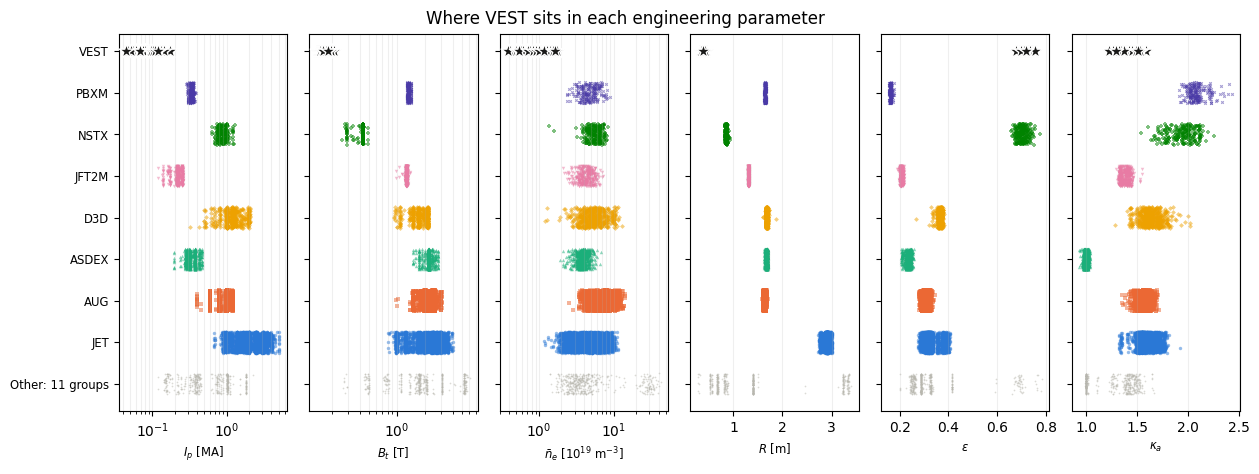

         rows  i_p_A  b_t_T  n_e_line_avg_m3  p_loss_W  tau_e_th_s  r_geo_m  epsilon  kappa  kappa_area  delta  m_eff_amu
machine                                                                                                                  
AUG      2155   2155   2155             2155      2155        2141     2155     2155   2155        2155   2155       2155
JET      3101   3101   3101             3101      3101        3101     3101     3101   3101        3101   3101       3101
MAST       43     43     43               43        43          43       43       43     43          43     39         43
NSTX      230    230    230              230       230         230      230      230    230         230    230        230
START       8      8      8                8         8           8        8        8      8           8      8          8
VEST       59     59     59               31        59          59       59       59     59          59     59         59

In [ ]:
fig, _ = population.confinement_coverage_strip(confinement)
fig.suptitle("Where VEST sits in each engineering parameter", y=1.02)
plt.show()
coverage_by_machine = public.confinement_coverage(confinement)
coverage_by_machine.loc[coverage_by_machine.index.intersection(["VEST", "JET", "AUG", "NSTX", "MAST", "START"])]

## 3. Kinetic and transport profiles

A PR08 discharge is four released files: global quantities, time traces, radial profiles
against time, and a comment file. PR08's radial coordinate is `sqrt(Phi/Phi_a)`, the IMAS
`rho_tor_norm`, so it needs no conversion. Signals sit on different radial grids, and nothing
is interpolated: each IDS block keeps its reference signal's grid, and every variable left
out is listed with its reason in section 6.

The mapped ODSs are drawn with the **same canonical renderers** as VEST -- there is no
PR08-specific plotting code.

In [ ]:
pr08 = {}
for label, machine, shot in (("MAST 8302", "mast", 8302), ("DIII-D 81507", "d3d", 81507),
                             ("JET 19649", "jet", 19649)):
    discharge = attempt(f"PR08 {label}", lambda m=machine, s=shot: public.fetch_pr08(m, s))
    if discharge is not None:
        pr08[label] = discharge
pr08_ods = {label: public.pr08_to_omas(discharge) for label, discharge in pr08.items()}

def heated_slice(ods):
    # Slice of peak beam electron heating, so a time-resolved discharge is
    # compared in its heated phase; 0 when there is no beam source.
    for index in range(len(ods["core_sources.source"]) if "core_sources.source" in ods else 0):
        if ods[f"core_sources.source.{index}.identifier.name"] == "nbi":
            root = f"core_sources.source.{index}.profiles_1d"
            peaks = [np.nanmax(np.asarray(ods[f"{root}.{t}.electrons.energy"])) for t in range(len(ods[root]))]
            return int(np.nanargmax(peaks))
    return 0


chosen = {label: heated_slice(ods) for label, ods in pr08_ods.items()}
for label, ods in pr08_ods.items():
    times = np.asarray(ods["core_profiles.time"])
    print(f"{label}: {len(times)} profile time(s); drawn at slice {chosen[label]}, "
          f"t = {times[chosen[label]]:.3f} s")

MAST 8302: 1 profile time(s); drawn at slice 0, t = 0.190 s
DIII-D 81507: 1 profile time(s); drawn at slice 0, t = 3.800 s
JET 19649: 161 profile time(s); drawn at slice 85, t = 48.251 s


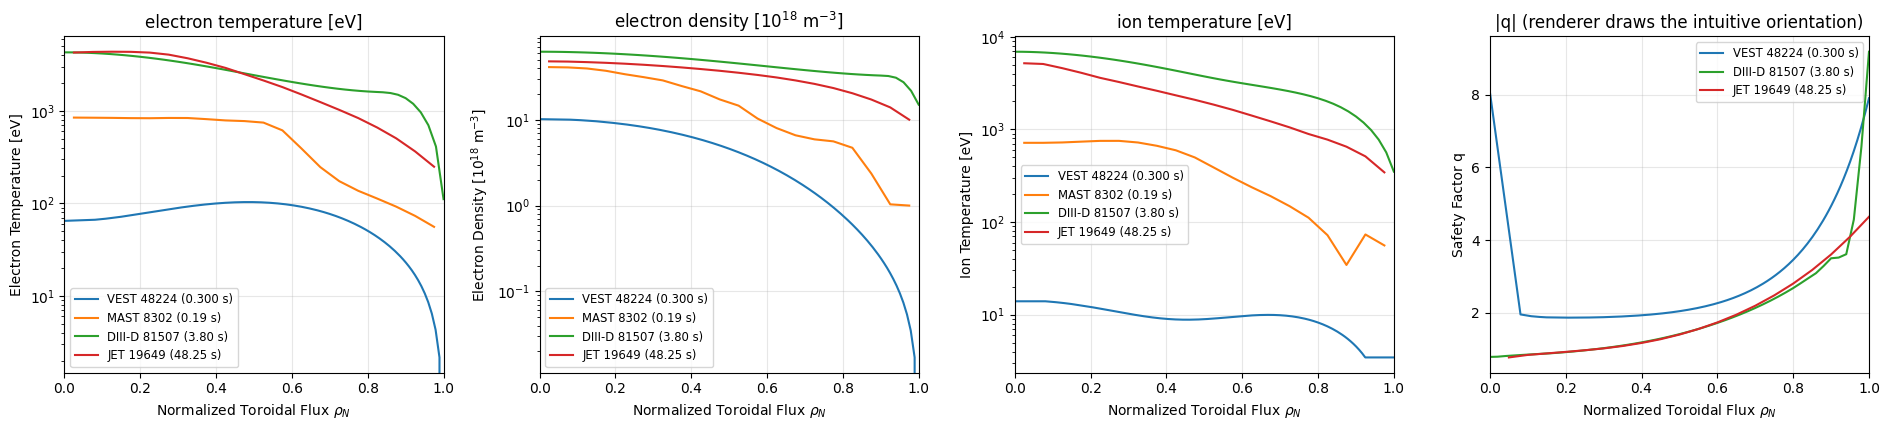

The ODSs store q signed (COCOS 11) where the current and field directions are known; the q panel draws |q|.


In [ ]:
def slice_label(label, ods, index):
    return f"{label} ({float(ods['core_profiles.time'][index]):.2f} s)"


# One renderer call per time slice index, all on the same axes.
groups = {0: ([vest_ods], ["VEST 48224 (0.300 s)"])}
for label, ods in pr08_ods.items():
    entries_, labels_ = groups.setdefault(chosen[label], ([], []))
    entries_.append(ods)
    labels_.append(slice_label(label, ods, chosen[label]))

fig, axes = plt.subplots(1, 4, figsize=(19, 4.4))
for index, (entries, labels) in groups.items():
    vaft.omas.plot_electron_temperature_profile(entries, label=labels, time_slice=index, ax=axes[0])
    vaft.omas.plot_electron_density_profile(entries, label=labels, time_slice=index, ax=axes[1])
    vaft.omas.plot_ion_temperature_profile(entries, label=labels, time_slice=index, ax=axes[2])
    vaft.omas.plot_equilibrium_profile_q(entries, label=labels, coordinate="rho_tor_norm",
                                         time_slice=index, ax=axes[3])

# One colour per machine in every panel (q has no MAST line), and titles that
# name no single shot.
machine_colour = {"VEST": "C0", "MAST": "C1", "DIII-D": "C2", "JET": "C3"}
titles = ("electron temperature [eV]", r"electron density [$10^{18}$ m$^{-3}$]",
          "ion temperature [eV]", "|q| (renderer draws the intuitive orientation)")
for ax, title in zip(axes, titles):
    for line in ax.get_lines():
        for machine, colour in machine_colour.items():
            if str(line.get_label()).startswith(machine):
                line.set_color(colour)
    ax.legend(fontsize="small")
    ax.set_title(title)
for ax in axes[:3]:
    ax.set_yscale("log")
fig.tight_layout()
plt.show()
print("The ODSs store q signed (COCOS 11) where the current and field directions are known; "
      "the q panel draws |q|.")

Each discharge is drawn at its slice of peak beam heating (JET 19649 carries 161; its early
slices are ohmic). The VEST q value at the axis (about 8) is the value stored in the packaged
kinetic-EFIT sample, not a feature of the mapping. MAST 8302 is missing
from the q panel: its release gives the plasma current opposite signs in the 0D and 1D files,
so the COCOS 11 sign of q cannot be fixed and q was not written (section 6). VEST 48224's
`rho_tor_norm` agrees with `sqrt(Phi/Phi_b)` to within 0.04, so the horizontal axes are the
same coordinate.

Transport and sources have no canonical renderer yet, so they are read directly from the
IDSs. The power-balance electron diffusivity and the electron heating by beams follow. Power
balance can return a non-positive diffusivity where the heat flux and the gradient disagree --
MAST 8302 at rho = 0.25 and DIII-D 81507 at the edge -- and those points appear as gaps on the
logarithmic axis. They are the released values, not a mapping artefact. JET 19649 releases no
power-balance diffusivity, so it is absent from the left panel.

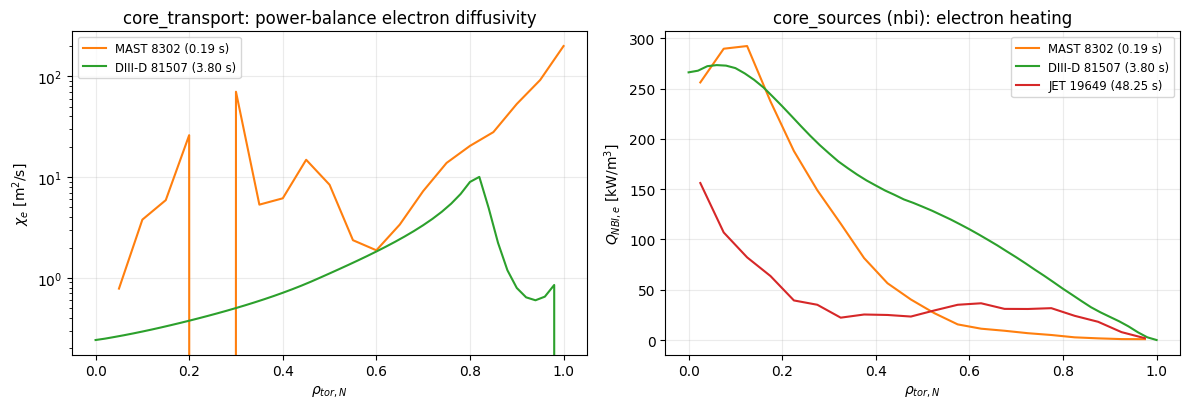

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for label, ods in pr08_ods.items():
    t = chosen[label]
    name = slice_label(label, ods, t)
    if f"core_transport.model.0.profiles_1d.{t}.electrons.energy.d" in ods:
        slice_ = f"core_transport.model.0.profiles_1d.{t}"
        axes[0].plot(ods[f"{slice_}.grid_d.rho_tor_norm"], ods[f"{slice_}.electrons.energy.d"],
                     label=name, color=machine_colour[label.split()[0]])
    for index in range(len(ods["core_sources.source"]) if "core_sources.source" in ods else 0):
        if ods[f"core_sources.source.{index}.identifier.name"] == "nbi":
            slice_ = f"core_sources.source.{index}.profiles_1d.{t}"
            axes[1].plot(ods[f"{slice_}.grid.rho_tor_norm"],
                         np.asarray(ods[f"{slice_}.electrons.energy"]) / 1e3, label=name,
                         color=machine_colour[label.split()[0]])
axes[0].set(xlabel=r"$\rho_{tor,N}$", ylabel=r"$\chi_e$ [m$^2$/s]", yscale="log",
            title="core_transport: power-balance electron diffusivity")
axes[1].set(xlabel=r"$\rho_{tor,N}$", ylabel=r"$Q_{NBI,e}$ [kW/m$^3$]",
            title="core_sources (nbi): electron heating")
for ax in axes:
    ax.grid(alpha=0.25)
    ax.legend(fontsize="small")
fig.tight_layout()
plt.show()

## 4. Confinement-regime transitions

A transition is an event, and the canonical transition table names it: `transition = L_to_H`,
`source_regime = L_mode`, `target_regime = H_mode`. A record where the transition was sought
and not seen keeps the same event with `transition_observed = False`. `time_s` is when the
conditions were taken; `transition_time_s` is the event itself.

The TCV public set is fetched. TC-26 is read from `$VAFT_TC26_CSV` when it is set. Both land
in one table and one set of plots.

In [ ]:
tcv = attempt("TCV L-H", lambda: public.normalize_tcv_lh(public.read_tcv_lh()))
tc26_path = os.environ.get("VAFT_TC26_CSV")
if tc26_path:
    tc26 = attempt("ITPA TC-26", lambda: public.normalize_tc26(public.read_tc26(tc26_path)))
else:
    tc26 = None
    status["ITPA TC-26"] = "skipped -- set VAFT_TC26_CSV to a local nfae39f2supp2.csv"

transitions = public.validate_transition_table(
    pd.concat([t for t in (tcv, tc26) if t is not None], ignore_index=True)
) if (tcv is not None or tc26 is not None) else public.empty_transition_table()

print("TCV has no standard-set flag of its own, so its 'selected' count is 0 by construction.")
transitions.groupby("machine").agg(
    records=("record_id", "size"),
    observed=("transition_observed", "sum"),
    selected=("selected", "sum"),
    main_ions=("main_ion", lambda s: ", ".join(sorted(s.dropna().unique()))),
    first_wall=("first_wall", "first"),
)

TCV has no standard-set flag of its own, so its 'selected' count is 0 by construction.


         records  observed  selected main_ions first_wall
machine                                                  
TCV           92        84         0  D, H, He       None

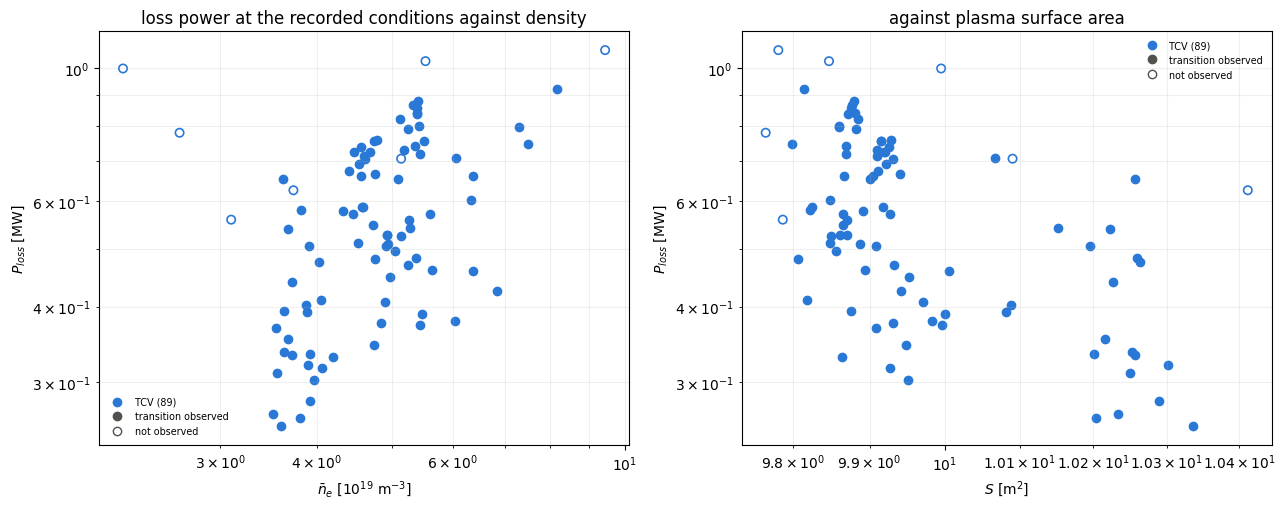

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
population.lh_threshold_population(transitions, by="machine", log=True, ax=axes[0])
population.lh_threshold_population(transitions, x="surface_area_m2", by="machine", log=True, ax=axes[1])
axes[0].set_title("loss power at the recorded conditions against density")
axes[1].set_title("against plasma surface area")
fig.tight_layout()
plt.show()

Legend counts are records with both plotted quantities present: three TCV records have no
loss power. "Recorded conditions" are the L-mode just before the transition for TC-26, and the
transition itself for TCV (see `time_s` and `transition_time_s`).

VAFT has no L–H threshold scaling in `vaft.formula` yet (#670, #1066), so VAFT predicts nothing
here. The TCV file carries the Martin 2008 value its authors computed, and
`p_lh_scaling_definition` says so on every row. TC-26 carries no prediction, so its margin is
missing rather than invented.

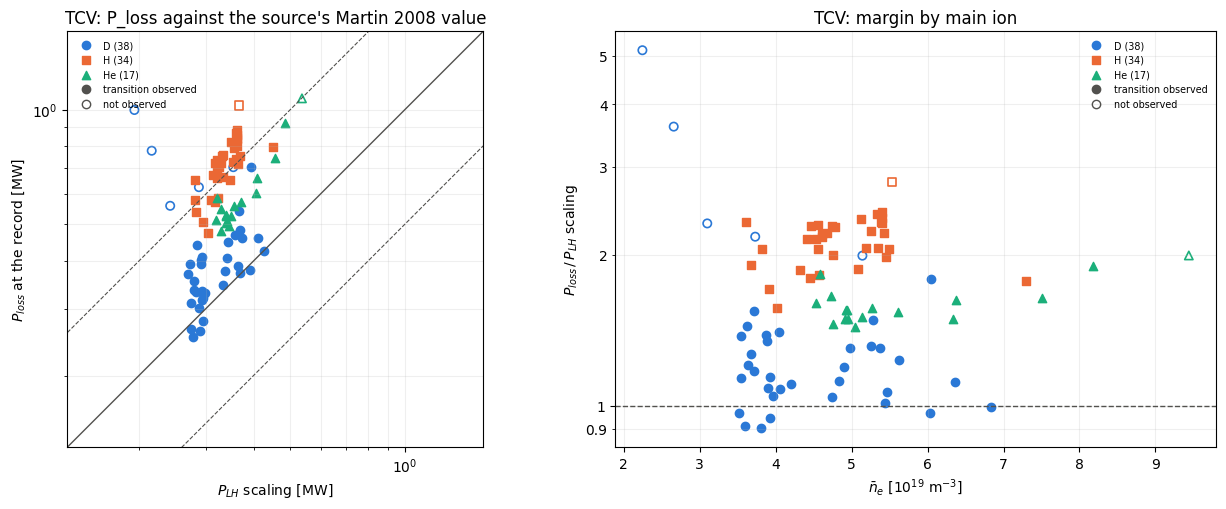

median margin over records where the transition was observed:


machine  main_ion
TCV      D           1.14
         H           2.15
         He          1.55
Name: transition_margin, dtype: float64

In [ ]:
tcv_only = transitions[transitions["machine"] == "TCV"].reset_index(drop=True)
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
population.transition_predicted_vs_measured(tcv_only, ax=axes[0])
population.transition_margin(tcv_only, public.transition_margin(tcv_only), ax=axes[1])
axes[0].set_title("TCV: P_loss against the source's Martin 2008 value")
axes[1].set_title("TCV: margin by main ion")
fig.tight_layout()
plt.show()
margin = public.transition_margin(transitions)
observed = transitions["transition_observed"]
print("median margin over records where the transition was observed:")
margin[observed].groupby([transitions.loc[observed, "machine"],
                          transitions.loc[observed, "main_ion"]]).median().dropna().round(2)

## 5. VEST multi-shot comparison (Tier A)

VEST enters the same tables in the same schema: the Tier A rows of section 2, one per
quasi-stationary EFIT slice. Lane D's confinement analysis of these rows -- regression with errors
clustered by shot, identifiability, the Kadomtsev completion and the Bohm / gyro-Bohm comparison --
lives in `confinement_time_scaling.ipynb`; this section only places them among the spherical
tokamaks of DB5, the population VEST is closest to.

The shot-scale route through the database summary,

```python
summary = vaft.database.summary(shot_range, preset="core_profiles")
vest_population = public.vest_summary_to_confinement_table(summary, effective_mass_amu=1.0)
```

remains available, but its loss power uses the Spitzer heating integral with hidden defaults
(#1188) and subtracts modelled radiation, so it is not the one shown here.

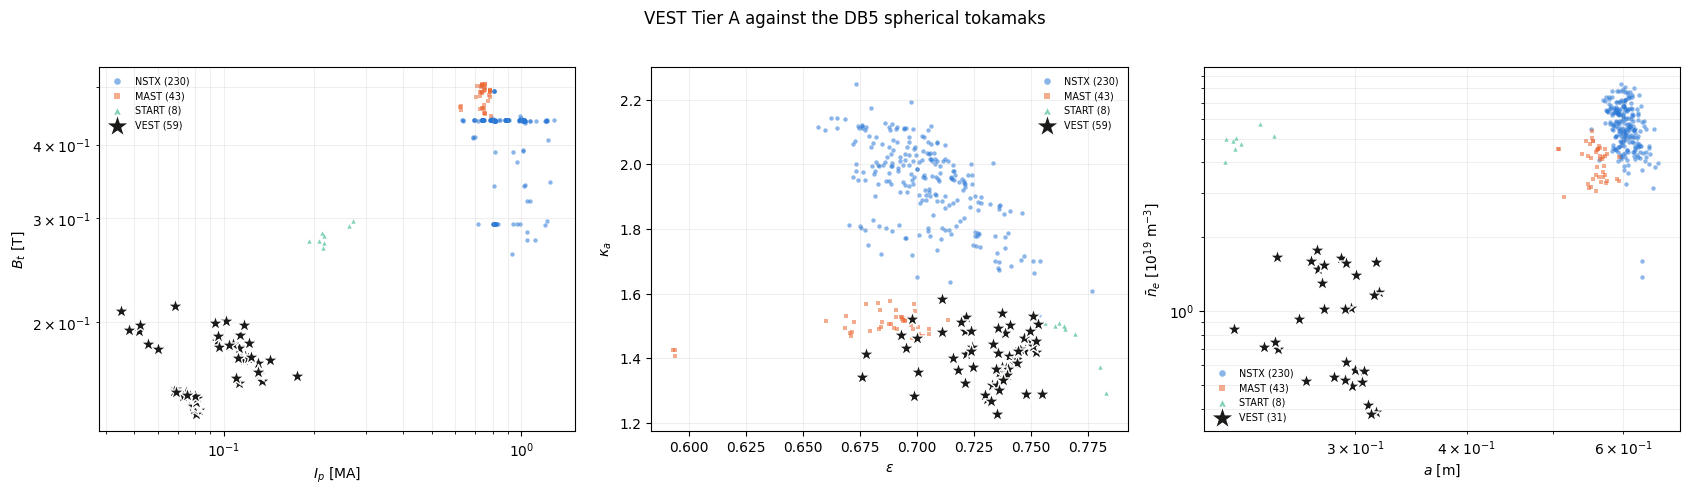

In [ ]:
spherical = confinement[confinement["machine"].isin(["NSTX", "MAST", "START", "VEST"])]
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
population.confinement_population(spherical, "i_p_A", "b_t_T", ax=axes[0])
population.confinement_population(spherical, "epsilon", "kappa_area", log=False, ax=axes[1])
population.confinement_population(spherical, "a_m", "n_e_line_avg_m3", ax=axes[2])
fig.suptitle("VEST Tier A against the DB5 spherical tokamaks", y=1.02)
fig.tight_layout()
plt.show()

For transitions, VEST has no L–H detector yet. When #1066 provides one, its events belong in
the transition table above, with `transition_observed` and the same definitions -- no separate
plotting path.

## 6. IMAS mapping coverage and limitations

**What maps to IMAS and what does not.** Profile databases map cleanly into IDSs, and the
coverage of every released variable is listed below. Global and transition databases stay tables:
they hold thousands of scalar records, and an L–H event is not an IDS quantity. Forcing either
into ODS would hide the semantics.

In [ ]:
if pr08:
    coverage = pd.concat(
        {label: public.pr08_mapping_coverage(discharge) for label, discharge in pr08.items()},
        names=["discharge"],
    ).reset_index(level=0)
else:
    coverage = pd.DataFrame(columns=["discharge", "variable", "status", "target", "reason"])
    print("No PR08 discharge could be fetched; see the status summary in section 7.")
coverage.groupby(["discharge", "status"]).size().unstack(fill_value=0)

status        mapped  unmapped
discharge                     
DIII-D 81507      20        27
JET 19649         12        36
MAST 8302         16        53

In [ ]:
(coverage[coverage["status"] != "mapped"]
 .groupby("reason")["variable"]
 .agg(lambda names: ", ".join(sorted(set(names))))
 .to_frame("variables"))

                                                                                                                                                                            variables
reason                                                                                                                                                                               
<|grad rho|> with dimensionless rho; IMAS gm7 needs rho_tor in m                                                                                                                GRHO1
<|grad rho|^2> with dimensionless rho; IMAS gm3 needs rho_tor in m                                                                                                              GRHO2
IP sign differs between the 0D ([-1.0]) and 1D ([1.0]) files; current direction ambiguo...                                                                                  BT, IP, Q
b0 needs a BT sample at every equilibrium time and a single 0D RGEO                       

**Definitions that differ between sources.** They are carried on every row and never merged.
The table below is read from the data, not written by hand.

In [ ]:
definition_columns = ["p_loss_definition", "tau_e_definition", "b_t_definition", "n_e_definition"]
confinement_definitions = (confinement.groupby("source_database")[definition_columns]
                           .first().T)
confinement_definitions

source_database                                                      ITPA global H-mode confinement database  \
p_loss_definition  DB5 PLTH = PL - PFLOSS, PL = POHM + auxiliary heating - dW/dt (machine-specific terms)...   
tau_e_definition                                                                      DB5 TAUTH = WTH / PLTH   
b_t_definition                                                         DB5 BT: vacuum toroidal field at RGEO   
n_e_definition     DB5 NEL: central line-averaged density from interferometry (approximated where NELFORM...   

source_database                                                  VAFT Lane D Tier A confinement table (#548)  
p_loss_definition  P_net = P_OH - dW/dt, P_OH = I_p V_res from the measured inboard loop voltage minus th...  
tau_e_definition   W_mhd / P_net; W_mhd = 1.5 int p dV of the magnetics EFIT; tau_e_kin_s = W_kin / P_net...  
b_t_definition                                                     vacuum field |b0 r0| / r_geo_m, as DB5 

In [ ]:
transition_definitions = (transitions.groupby("source_database")[
    ["p_loss_definition", "p_rad_definition", "isotope_definition",
     "density_branch_definition", "p_lh_scaling_definition"]].first().T)
transition_definitions

source_database                                                        TCV L-H transition database (limited dataset)
p_loss_definition          TCV PLMW = PTOTMW_A - DWMHDMW_A: ASTRA coupled power (ohmic + absorbed NBI + ECH) minu...
p_rad_definition                                                                      TCV PRAD: total radiated power
isotope_definition         main_ion = fuelling species from the source's A and Z (not purity); hydrogen_fraction ...
density_branch_definition  n_e_min_m3 = source nRyter (Ryter 2014 minimum-threshold density, source-computed); 'l...
p_lh_scaling_definition    source PLH: Martin 2008 ITPA scaling 0.0488 n20^0.717 B^0.803 S^0.941 [MW], source-com...

Consequences to keep in mind when reading the figures:

* **Loss power.** DB5, TCV and TC-26 do not subtract radiation, and neither do the Tier A rows
  shown here ($P_{OH} - dW/dt$). The VEST `core_profiles` summary does, and takes its heating power
  from a Spitzer integral with hidden defaults (#1188); its stored-energy factor was fixed in #1410.
* **Stored energy.** The Tier A $W$ is the magnetics-EFIT $1.5\int p\,dV$. 84 % of the 429xx--430xx
  Thomson-matched slices are Thomson-inconsistent (criteria v2, #1521), where it runs high; the
  `thomson_consistent` column marks them (#1490).
* **Elongation.** IPB98(y,2) uses the area elongation `kappa_area`. The Tier A rows compute it
  from the EFIT volume; the VEST summary carries only the boundary elongation, so its H98 needs
  `kappa_column="kappa"`, chosen explicitly.
* **Field.** DB5 and TC-26 quote the vacuum field at `RGEO`. The VEST adapters rescale to the
  geometric radius and say how.
* **Species.** TCV "H" plasmas contain 10–35 % D (CNPA), so `main_ion` is the fuelling species and
  `hydrogenic_mix` classifies the mixture. TC-26 gives only an effective mass.
* **Radiation.** TC-26 `p_rad_W` is core radiation; TCV's is total.
* **PR08 q sign.** PR08 stores |q|. MAST 8302's current direction contradicts itself between its
  0D and 1D files, so its q, Ip and B0 are left out of the ODS.

## 7. Reproducibility and provenance summary

In [ ]:
rows = []
for key, source in public.SOURCES.items():
    rows.append({"dataset": source.release, "file": source.filename,
                 "sha256": source.sha256[:16], "verification": "pinned"})
for label, discharge in pr08.items():
    for kind, digest in sorted(discharge.files.items()):
        rows.append({"dataset": f"PR08 {label}", "file": kind, "sha256": digest[:16],
                     "verification": discharge.verification.get(kind, "read locally")})
if tc26 is not None:
    digest = TC26_SHA256
    rows.append({"dataset": "ITPA TC-26", "file": "nfae39f2supp2.csv", "sha256": digest[:16],
                 "verification": "local copy, hash checked against the reader's release"})
pd.DataFrame(rows)

                         dataset                        file            sha256 verification
0                        DB5.2.3                 DB5.2.3.csv  7a48e34379663e3e       pinned
1   Zenodo 14996664 (2025-03-09)  tcv_lhdatabase_14996664.h5  afdd584ab33e0da5       pinned
2                 PR08 MAST 8302                          0d  b3783c0936c76b40       pinned
3                 PR08 MAST 8302                          1d  897ae40a9f91a588       pinned
4                 PR08 MAST 8302                          2d  9806d5de04f95936       pinned
5                 PR08 MAST 8302                         com  5c713817220ae550       pinned
6              PR08 DIII-D 81507                          0d  c02217ad9450fb85       pinned
7              PR08 DIII-D 81507                          1d  df5189960f1e1977       pinned
8              PR08 DIII-D 81507                          2d  9fd3e67dc84a5cbd       pinned
9              PR08 DIII-D 81507                         com  75a11da44c802486  

In [ ]:
import importlib.metadata as metadata

for name, state in status.items():
    print(f"{name:<14} {state}")
print()
print("run date (UTC):", datetime.datetime.now(datetime.timezone.utc).date().isoformat())
for package in ("vaft", "omas", "numpy", "pandas"):
    try:
        print(f"{package:<8}", metadata.version(package))
    except metadata.PackageNotFoundError:
        print(f"{package:<8}", "not installed as a distribution")

DB5.2.3        ok
PR08 MAST 8302 ok
PR08 DIII-D 81507 ok
PR08 JET 19649 ok
TCV L-H        ok
ITPA TC-26     skipped -- set VAFT_TC26_CSV to a local nfae39f2supp2.csv

run date (UTC): 2026-10-02
vaft     0.7.0
omas     0.94.2
numpy    2.4.3
pandas   3.0.1


### Feedback to the design issues

* **#670** (scaling API): the confinement table feeds the existing `tau_E` scalings unchanged, and
  reproducing DB5's own H-factor is a ready regression test. The L–H threshold scalings (Martin
  2008, TC-26) are the missing piece, and both transition databases are waiting for them.
* **#1066** (transitions): the event record needs *two* times, when the conditions were taken and
  when the event happened, and an explicit `transition_observed`. TC-26 shows conditions recorded
  after the transition on 14 rows.
* **#1084 / #1165 / #1167**: the VEST summary lacks the plasma volume (so no `kappa_area`) and
  the ion mass. A `Study` over these tables would need the definition columns as part of its
  query, not only the values.